In [86]:
import json

word2vec = json.load(open('vocab.json', 'r'))

print(word2vec['def'])
print(list(word2vec.keys())[:10]) 


number_to_token = dict((num, token) for token, num in word2vec.items())

58
['<PAD>', '<UNK>', '.', '(', ')', ',', '"', '=', ':', ';']


## dla ig

In [88]:
mypath = "feature_importance/ig/"
from os import listdir
from os.path import isfile, join
ig_files = [f for f in listdir(mypath) if isfile(join(mypath, f))]
print(ig_files)
languages = list(set([x.split("_")[0] for x in ig_files]))
print(languages)


['assembly_negative.csv', 'assembly_positive.csv', 'c++_negative.csv', 'c++_positive.csv', 'c-sharp_negative.csv', 'c-sharp_positive.csv', 'go_negative.csv', 'go_positive.csv', 'java_negative.csv', 'java_positive.csv', 'prolog_negative.csv', 'prolog_positive.csv', 'python_negative.csv', 'python_positive.csv', 'verilog_negative.csv', 'verilog_positive.csv']
['go', 'python', 'prolog', 'c-sharp', 'verilog', 'assembly', 'java', 'c++']


['dump', 'flush', 'buffer_size', 'asString', 'LittleEndian', 'Solution', 'ifndef', 'pch', 'once', '\ufeff'] [0.0, 0.0, 0.0, 0.0, 0.0, 0.217946, 0.239342, 0.311682, 0.33062, 0.514004]


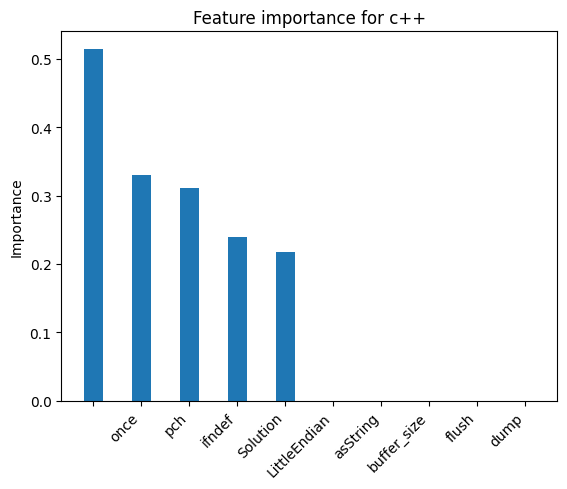

In [89]:
import csv
tokens, importance = [], []
for type in range(2):
    file = ig_files[2+type]
    csv_file = csv.reader(open(mypath + file, "r"), delimiter=",")
    
    for row in list(list(csv_file)[1:6])[::-1]:
        tokens.append(number_to_token[int(row[1])])
        importance.append(float(row[2]))

print(tokens, importance)
fig, ax   = plt.subplots()

ax.bar(tokens[::-1], importance[::-1], width=0.4)
ax.set_ylabel("Importance")
ax.set_title("Feature importance for " + file.split("_")[0])
ax.set_xticks(tokens[::-1])
ax.set_xticklabels(tokens[::-1], rotation=45, ha="right")
plt.show()


c++_negative.csv


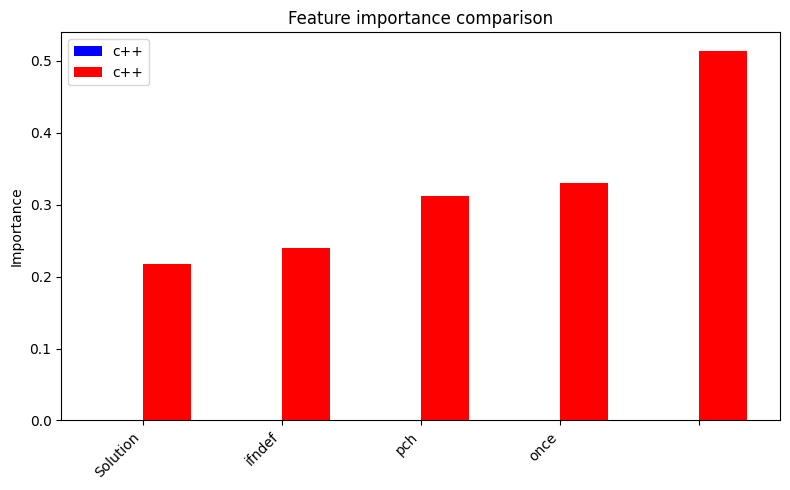

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_feature_importance(number_of_file_in_list):
    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ["blue", "red"]
    width = 0.35
    labels = None

    for type_idx in range(2):
        file = ig_files[number_of_file_in_list + type_idx]

        with open(mypath + file, "r") as f:
            rows = list(csv.reader(f, delimiter=","))[1:6][::-1]

        tokens = [number_to_token[int(row[1])] for row in rows]
        importance = [float(row[2]) for row in rows]

        x = np.arange(len(tokens))
        offset = -width/2 if type_idx == 0 else width/2

        ax.bar(
            x + offset,
            importance,
            width=width,
            color=colors[type_idx],
            label=file.split("_")[0]
        )

        labels = tokens

    ax.set_ylabel("Importance")
    ax.set_title("Feature importance comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.show()


print(ig_files[2])
plot_feature_importance(2)


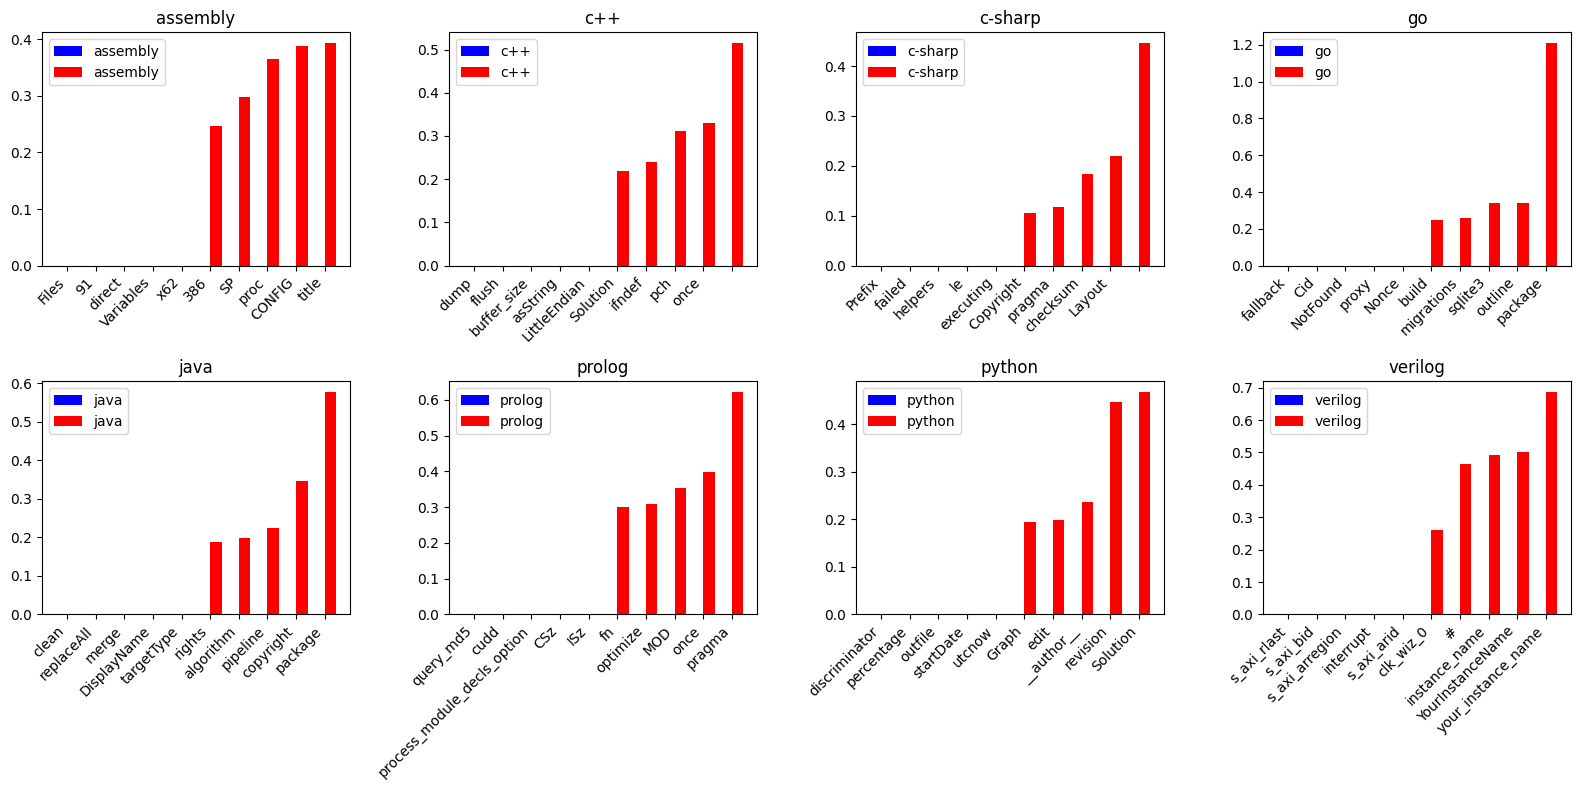

In [91]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, file_idx in enumerate(range(0, len(ig_files), 2)):
    plot_feature_importance(file_idx, axes[i])

plt.tight_layout()
plt.show()

In [90]:
def plot_feature_importance(file_idx, ax):
    colors = ["blue", "red"]

    all_tokens = []
    data = []

    # --- wczytaj oba pliki ---
    for type_idx in range(2):
        file = ig_files[file_idx + type_idx]

        with open(mypath + file, "r") as f:
            rows = list(csv.reader(f, delimiter=","))[1:6][::-1]

        tokens = [number_to_token[int(row[1])] for row in rows]
        importance = [float(row[2]) for row in rows]

        all_tokens.append(tokens)
        data.append((tokens, importance, colors[type_idx], file.split("_")[0]))

    # --- wspólna oś kategorii (union) ---
    unique_tokens = list(dict.fromkeys(all_tokens[0] + all_tokens[1]))
    x = np.arange(len(unique_tokens))
    width = 0.4

    # --- rysowanie ---
    for i, (tokens, importance, color, label) in enumerate(data):
        values_aligned = []

        for t in unique_tokens:
            if t in tokens:
                idx = tokens.index(t)
                values_aligned.append(importance[idx])
            else:
                values_aligned.append(0)  # brak tokena

        offset = -width/2 if i == 0 else width/2

        ax.bar(
            x + offset,
            values_aligned,
            width=width,
            color=color,
            label=label
        )

    ax.set_title(ig_files[file_idx].split("_")[0])
    ax.set_xticks(x)
    ax.set_xticklabels(unique_tokens, rotation=45, ha="right")
    ax.legend()

### occlusion

In [92]:
mypath = "feature_importance/occlusion/"
from os import listdir
from os.path import isfile, join
oclusion_files = [f for f in listdir(mypath) if isfile(join(mypath, f))]
print(oclusion_files)

languages = list(set([x.split("_")[0] for x in oclusion_files]))
print(languages)




['assembly_negative.csv', 'assembly_positive.csv', 'c++_negative.csv', 'c++_positive.csv', 'c-sharp_negative.csv', 'c-sharp_positive.csv', 'go_negative.csv', 'go_positive.csv', 'java_negative.csv', 'java_positive.csv', 'prolog_negative.csv', 'prolog_positive.csv', 'python_negative.csv', 'python_positive.csv', 'verilog_negative.csv', 'verilog_positive.csv']
['go', 'python', 'prolog', 'c-sharp', 'verilog', 'assembly', 'java', 'c++']


In [97]:
def plot_feature_importance(file_idx, ax):
    colors = ["blue", "red"]

    all_tokens = []
    data = []

    # --- wczytaj oba pliki ---
    for type_idx in range(2):
        file = oclusion_files[file_idx + type_idx]

        with open(mypath + file, "r") as f:
            rows = list(csv.reader(f, delimiter=","))[1:6][::-1]

        tokens = [number_to_token[int(row[1])] for row in rows]
        importance = [float(row[2]) for row in rows]

        all_tokens.append(tokens)
        data.append((tokens, importance, colors[type_idx], file.split("_")[0]))

    # --- wspólna oś kategorii (union) ---
    unique_tokens = list(dict.fromkeys(all_tokens[0] + all_tokens[1]))
    x = np.arange(len(unique_tokens))
    width = 0.4

    # --- rysowanie ---
    for i, (tokens, importance, color, label) in enumerate(data):
        values_aligned = []

        for t in unique_tokens:
            if t in tokens:
                idx = tokens.index(t)
                values_aligned.append(importance[idx])
            else:
                values_aligned.append(0)  # brak tokena

        offset = -width/2 if i == 0 else width/2

        ax.bar(
            x + offset,
            values_aligned,
            width=width,
            color=color,
            label=label
        )

    ax.set_title(oclusion_files[file_idx].split("_")[0])
    ax.set_xticks(x)
    ax.set_xticklabels(unique_tokens, rotation=45, ha="right")
    ax.legend()

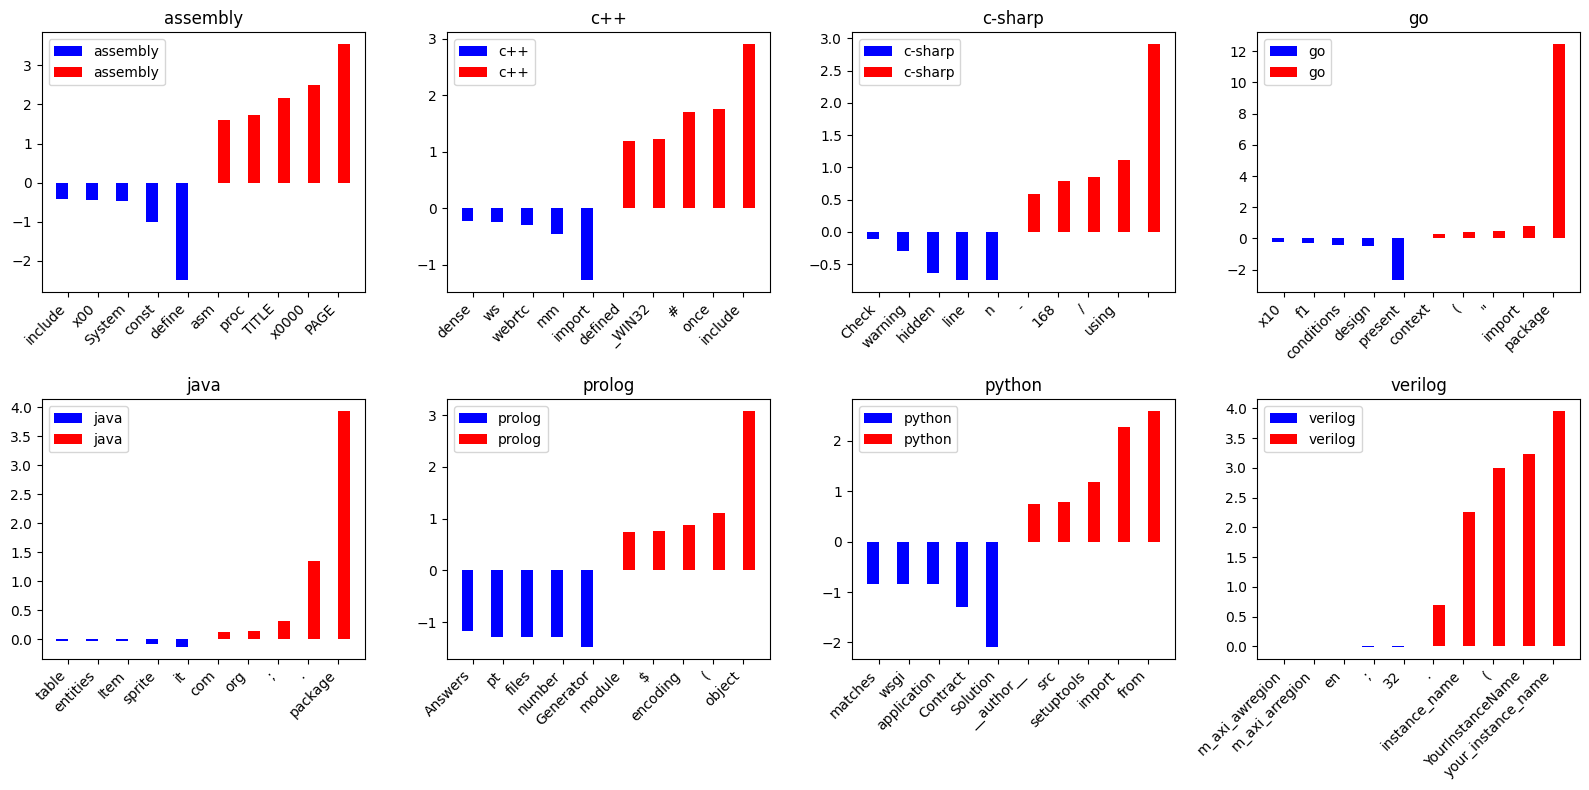

In [98]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, file_idx in enumerate(range(0, len(oclusion_files), 2)):
    plot_feature_importance(file_idx, axes[i])

plt.tight_layout()
plt.show()